In [1]:
import pandas as pd 
from tabulate import tabulate
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
import matplotlib.patches as patches

If you change the locations of anything, or would like to analyze different files, change the two values in the following cell.

# MASSIVE BORING LANG CLEANER DICTS

In [2]:
doom_list = ['jpg', 'sample', 'png', 'pack',  'svg',  'gif', 'wav', 'webp', 'glb',  'ico',  'map' , 'lock',  'pdf', 
             'jpeg',  'mts', 'scene',   'icns',  'mp4', 'ogg', 'pro', 'mod', 'tar', 'fbx',  'lockb',  'mp3', 'zip', 
             'obj',  'pxd', 'sq',  'standalone',  'vue', 'm4', 'milk',  'bmp', 'dfm',  'xpm', 'gz', 'rar', 'srt',  
             'au', 'ai', 'l',  'tgz',   'x' , 'y', '~dfm', '~63~', '~30~', '~31~', '~32~',  '~33~', '~34~', '~35~', 
             '~36~', '~37~', '~38~', '~39~', '~56~', '~57~', '~58~', '~59~', '~60~', '~61~', '~62~',  '~64~', '~65~',  
             'catalog',  'frx', 'def', 'hdr', 'mkv', 'otf', 'p', 'psd', 'smi', 'sofa',  'thumbnailer',  'voc', 'tiff' , 
             'vsp' , 'asset','json', 'csv', 'HEAD', 'zon', 'meta', 'gitignore', 'LICENSE']

lang_list = ['ts',  'tsx', 'markdown', 'md', 'mdx',  'xml', 'cs', 'py',  'js', 'mjs',  'cjs',  'ejs',  'rs',  'css', 
             'kt', 'html', 'sh',  'txt',  'sql',  'astro',  'go', 'c', 'cc',  'cpp',  'hpp', 'csproj',  'm',  'h', 
             'rb', 'tmlanguage', 'java', 'swift',  'ru', 'ipynb',  'bat',  'exe',  'kts', 'wasm',  'npmrc',  'nvmrc',  
             'sb',  'snap', 'http', 'ps1',  'php',  'woff2', 'sum', 'mako',  'ino',  'cmd',  'env', 'ahk',  'bash',  
             'erb', 'onnx',  'server', 'skill',  'tpl',  'class',  'mak', 'mk', 'lua', 's', 'dcu', 'less',  'pas',  
             'woff', 'scss', 'pyc', 'dpr', 'inc', 'res',  'resx',  'dproj',  'hex',  'idl',  'pl', 'bm2', 'dak',  
             'gradle',  'ld',  'rst' , 'wxs', 'bsd',  'el', 'htaccess',  'manifest', 'md~',  'vcxproj', '~pas',  
             'ap_',  'asm',  'bas',  'classpath',  'ddp',  'dex' , 'dist', 'htm',  'lircrc',  'makefile',  'odt', 
             'qml',  'qrc',  'rtf', 'sass', 'sch',  'skins2', 'tmpl', 'vbp', 'vbw',  'vim' , 'xsd', '~ddp', '~dpr', ]

lang_dict = {'ts': 'typescript', 'tsx':'typescript', 
             'markdown':'markdown', 'md':'markdown', 'mdx':'markdown', 'xml':'markdown', 'manifest':'markdown', 'md~':'markdown', 'htm':'markdown', 'qrc':'markdown',  'xsd':'markdown',
             'txt':'text',  'rst':'text', 'odt':'text',  'rtf':'text',
             'c':'C', 'm':'C',
             'cs':'C#',  'csproj':'C#',
             'cc':'C++', 'cpp':'C++', 'hpp':'C++', 'vcxproj':'C++',
              'py': 'Python', 'ipynb':'Python Notebook',  '.mako':'Python', 
             'js':'JavaScript', 'mjs':'JavaScript', 'cjs':'JavaScript', 'ejs':'JavaScript',  'astro':'JavaScript',
             'java':'Java', 'class':'Java',
             'rs': 'Rust',
             'css':'CSS', 'less':'CSS',  'scss':'CSS', 'sass':'CSS',
             'html': 'HTML',
             'http':'HTTP',
             'kt':'Kotlin', 'kts':'Kotlin',
             'sh':'Shell', 'bat':'Shell', 'exe':'Shell', 'ps1':'Shell', 'cmd':'Shell', 'ahk':'Shell', 'bash':'Shell', 'ld':'Shell',  'asm':'Shell', 'lircrc':'Shell',
             'sql':'SQL',  'server':'SQL',
             'go':'GO',
             'rb':'Ruby',  'erb':'Ruby',
             'swift':'Swift',
             'wasm':'Assembly', 's':'Assembly',
             'sb':'Scratch',
             'php':'Php',
             'woff2':'Web Open Front Format',  'woff':'Web Open Front Format',
             'sum':'Scilab',
             'ino':'Arduino',
             'skill':'Skill',
             'onnx':'Onnx',
             'tpl':'Template', 'inc':'Template', 'h':'Template', 'idl':'Template', 'classpath':'Template', 'tmpl':'Template',
             'mak':'Makefile', 'mk':'Makefile', 'makefile':'Makefile',
             'lua':'Lua',
             'dcu':'Delphi', 'pas':'Delphi', 'dpr':'Delphi', 'dproj':'Delphi', '~pas':'Delphi', 'ddp':'Delphi', '~ddp':'Delphi', '~dpr':'Delphi',
             'pyc':'Bytecode', 'hex':'Bytecode',
             'pl':'Perl',
             'bm2':'Boardmaker Interactive Board File',
             'dak':'Debian Archive Kit Data',
             'gradle':'Gradle',
             'bsd':'BSDL',
             'el':'LSP',
             'ap_':'Pascal',
             'bas':'Basic', 'vbp':'Basic',
             'dex':'Dalvik',
             'qml':'Qt SDK',
             'sch':'Circuitry',
             'skins2':'Skins',
             'tmlanguage':'Other', 'ru':'Other', 'snap':'Other',  'env':'Other', 'res':'Other','npmrc':'Other',  'nvmrc':'Other', 'resx':'Other', 'wxs':'Other', 'htaccess':'Other', 'dist':'Other', 'vbw':'Other',  'vim':'Other'
             
            }

# Actual code

In [3]:
files = "../dataset_features/files_raw.csv"
source = "../backups/exp_no_hist.csv"
names = ["Vibecoding", "SideProject"]

In [4]:
files_df = pd.read_csv(files)
files_df.drop_duplicates(inplace=True)
source_df = pd.read_csv(source, index_col=0)
source_df.drop_duplicates(inplace=True)

files_df["avg_char_line"] = files_df["n_characters"]/(files_df["lines"] - files_df["blank_lines"])

KeyError: 'n_characters'

In [ ]:
source_df

,url,commit,error,time_out,SideProject,Vibecoding
0,https://github.com/Skowt/Loadr,c2ead4af6a33aed6ed79684f2346de6a3f12fe5a,False,False,True,False
1,https://github.com/AI-Spawn/Save-The-Turtles,4747b9d40aeb6c1cbc73eb0802008c4afff686d9,False,False,True,False
2,https://github.com/YigitGunduc/cycle,26eb2a3b4b61505b7f21395e0165a1cee3973090,False,False,True,False
3,https://github.com/saurabh0719/jett,3f57c4a8a626678f27305c54d13237eb583c30b4,False,False,True,False
4,https://github.com/tn/climood,4dae3cae768245a169e8abeccb457558fac8c112,False,False,True,False
...,...,...,...,...,...,...
1152,https://github.com/empathy0/project_bundler,a9e265418cf0bbe2bd2249194c5651147455b5ec,False,False,False,True
1153,https://github.com/rm2thaddeus/Pixel_Detective,8e741807f9b04e4bbb5c1b5c6460cd271e600837,False,False,False,True
1154,https://github.com/TheRealSaiTama/Project-Chimera,21da80b493600a255e13945e15c020f0b07e567c,False,False,False,True
1155,https://github.com/johnhuang316/code-index-mcp,1a1407b6d594d682545b245ee7108c5b35546a90,False,False,False,True


In [ ]:
def make_mask(df_source, df_files, name):  
    mask = (df_source[name])
    name_df = df_source[mask]
    url_set = set(name_df["url"])
    mask = (df_files["url"].isin(url_set))
    masked_files = df_files[mask]
    return masked_files

In [ ]:
df_vc = make_mask(source_df, files_df, names[0])
df_sp = make_mask(source_df, files_df, names[1])

In [ ]:
len(df_sp)

157435

Cleaning the file names

In [ ]:
print(len(df_sp['extn'].value_counts()))
temp = df_sp['extn'].replace(lang_dict)
df_sp['extn_flt'] = temp
sp_cleaned = df_sp[~df_sp["extn"].isin(doom_list)]
sp_lang =  df_sp[df_sp["extn_flt"].isin(lang_list)]
print(len(sp_cleaned["extn_flt"].value_counts()))

1146
1081


In [ ]:
sp_cleaned["extn_flt"].value_counts()

extn_flt
C++               29564
typescript        12405
JavaScript         9411
GO                 8709
markdown           6921
                  ...  
STABLE_VERSION        1
ALPHA_VERSION         1
attest                1
ext                   1
ioc                   1
Name: count, Length: 1081, dtype: int64

/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_21058/996366363.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45)


[Text(0, 0, 'markdown'),
 Text(1, 0, 'CSS'),
 Text(2, 0, 'JavaScript'),
 Text(3, 0, 'C#'),
 Text(4, 0, 'C++'),
 Text(5, 0, 'Template'),
 Text(6, 0, 'GO'),
 Text(7, 0, 'typescript'),
 Text(8, 0, 'Java'),
 Text(9, 0, 'Python')]

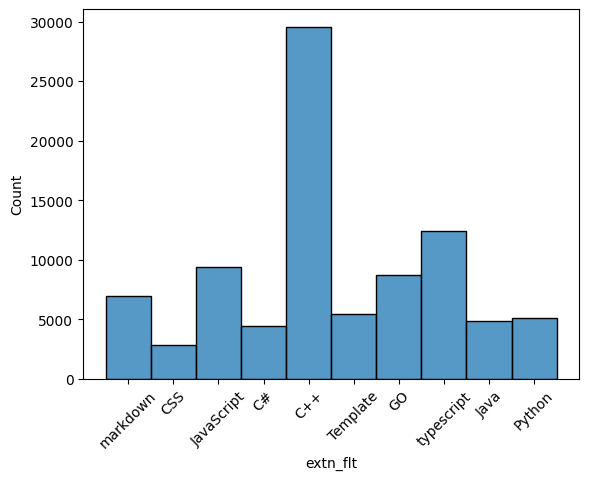

In [ ]:
#extn_count = df_sp['extn'].value_counts()[:10].rename_axis("extn").reset_index(name='counts')
extn_names = sp_cleaned['extn_flt'].value_counts()[:10].index.tolist()
mask = (sp_cleaned["extn_flt"].isin(extn_names))
df_sp_top_10 = sp_cleaned[mask]

plot = sns.histplot(df_sp_top_10, x="extn_flt")
plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

In [ ]:
print(len(df_vc['extn'].value_counts()))
temp = df_vc['extn'].replace(lang_dict)
df_vc['extn_flt'] = temp
vc_cleaned = df_vc[~df_vc["extn"].isin(doom_list)]
sp_lang =  df_vc[df_vc["extn_flt"].isin(lang_list)]
print(len(vc_cleaned["extn_flt"].value_counts()))

3949
3881


/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_21058/2079437049.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(), rotation=45)


[Text(0, 0, 'markdown'),
 Text(1, 0, 'typescript'),
 Text(2, 0, 'Template'),
 Text(3, 0, 'Shell'),
 Text(4, 0, 'Rust'),
 Text(5, 0, 'Python'),
 Text(6, 0, 'JavaScript'),
 Text(7, 0, 'C'),
 Text(8, 0, 'GO'),
 Text(9, 0, 'C#')]

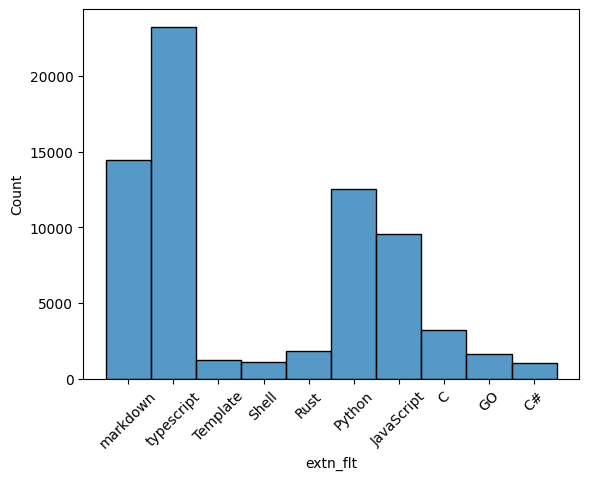

In [ ]:
extn_names = vc_cleaned['extn_flt'].value_counts()[:10].index.tolist()
mask = (vc_cleaned["extn_flt"].isin(extn_names))
df_sp_top_10 = vc_cleaned[mask]

plot= sns.histplot(df_sp_top_10.sort_values(by = ["extn"], ascending=False), x="extn_flt")
plot.set_xticklabels(plot.get_xticklabels(), rotation=45)

## Histogram

In [ ]:
extn_count_sp = df_sp['extn'].value_counts().rename_axis("extn").reset_index(name='counts')
extn_count_vc = df_vc['extn'].value_counts().rename_axis("extn").reset_index(name='counts')

In [ ]:
merged = pd.merge(extn_count_sp, extn_count_vc, on="extn", how="outer", suffixes=('_SideProject', '_Vibecoding')).fillna(0)
merged.head()
merged["sum"] = merged["counts_SideProject"] + merged["counts_Vibecoding"]
merged = merged[~merged["extn"].isin(doom_list)]
merged = merged.sort_values(by = ["sum"], ascending = False).reset_index(drop=True)
heatmap_data = merged.set_index("extn")[["counts_SideProject", "counts_Vibecoding"]]
print(heatmap_data.head())



      counts_SideProject  counts_Vibecoding
extn                                       
hpp              28773.0               16.0
ts                8540.0            14853.0
js                9312.0             8812.0
md                3870.0            13858.0
py                5061.0            12557.0


In [ ]:
merged.head()

,extn,counts_SideProject,counts_Vibecoding,sum
extn_flt,,,,
typescript,tstsx,12405.0,23239.0,35644.0
C++,cccpphppvcxproj,29564.0,104.0,29668.0
markdown,manifestmarkdownmdmdxqrcxmlxsd,6921.0,14412.0,21333.0
JavaScript,astrocjsejsjsmjs,9411.0,9548.0,18959.0
Python,py,5061.0,12557.0,17618.0


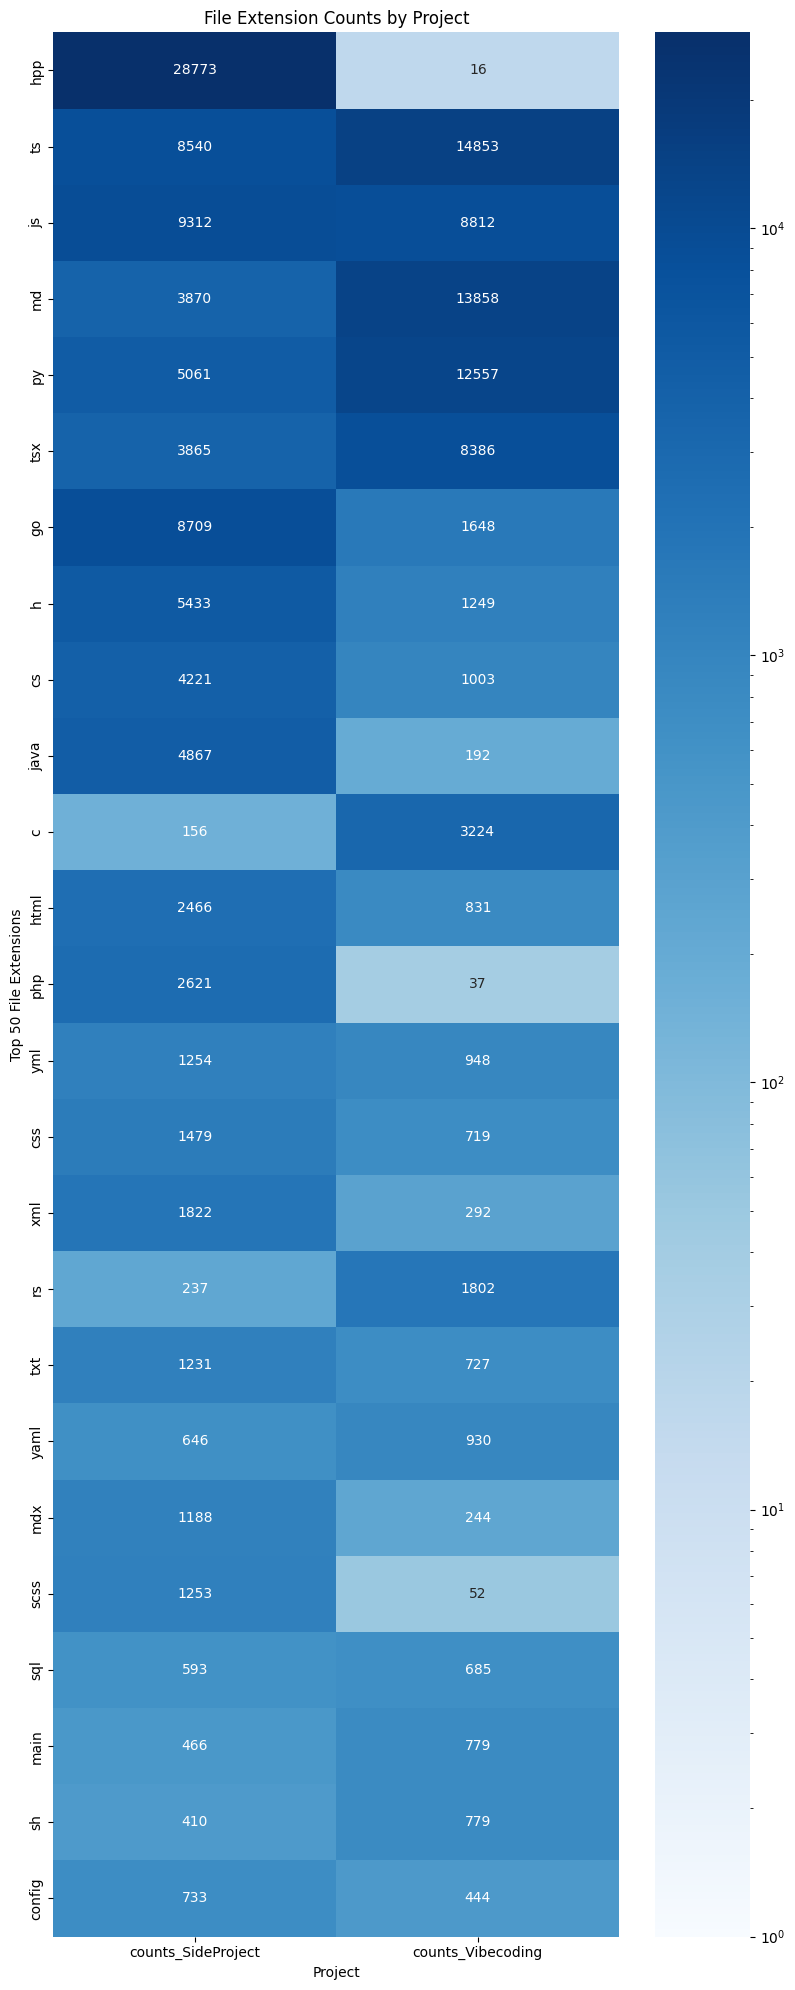

In [ ]:
plt.figure(figsize=(8, 20))
sns.heatmap(
heatmap_data[:25],
annot=True,
fmt=".0f",
cmap="Blues",
norm=LogNorm(vmin=max(1, heatmap_data[heatmap_data > 0].min().min()),
                vmax=heatmap_data.max().max())
)
plt.title("File Extension Counts by Project")
plt.xlabel("Project")
plt.ylabel("Top 50 File Extensions")
plt.tight_layout()
plt.show()

In [ ]:
merged = pd.merge(extn_count_sp, extn_count_vc, on="extn", how="outer", suffixes=('_SideProject', '_Vibecoding')).fillna(0)
temp = merged['extn'].replace(lang_dict)
merged['extn_flt'] = temp
merged["sum"] = merged["counts_SideProject"] + merged["counts_Vibecoding"]
merged = merged[~merged["extn"].isin(doom_list)]
merged =  merged[merged["extn"].isin(lang_list)]
merged = merged.groupby("extn_flt", as_index=True).sum()
merged = merged.sort_values(by = ["sum"], ascending = False) #.reset_index(drop=False)


heatmap_data = merged[["counts_SideProject", "counts_Vibecoding"]] #set_index("extn_flt")

print(heatmap_data)

                 counts_SideProject  counts_Vibecoding
extn_flt                                              
typescript                  12405.0            23239.0
C++                         29564.0              104.0
markdown                     6921.0            14412.0
JavaScript                   9411.0             9548.0
Python                       5061.0            12557.0
GO                           8709.0             1648.0
Template                     5469.0             1260.0
C#                           4393.0             1058.0
Java                         4867.0              192.0
CSS                          2862.0              771.0
C                             288.0             3233.0
HTML                         2466.0              831.0
Php                          2621.0               37.0
text                         1377.0              757.0
Rust                          237.0             1802.0
Shell                         525.0             1120.0
SQL       

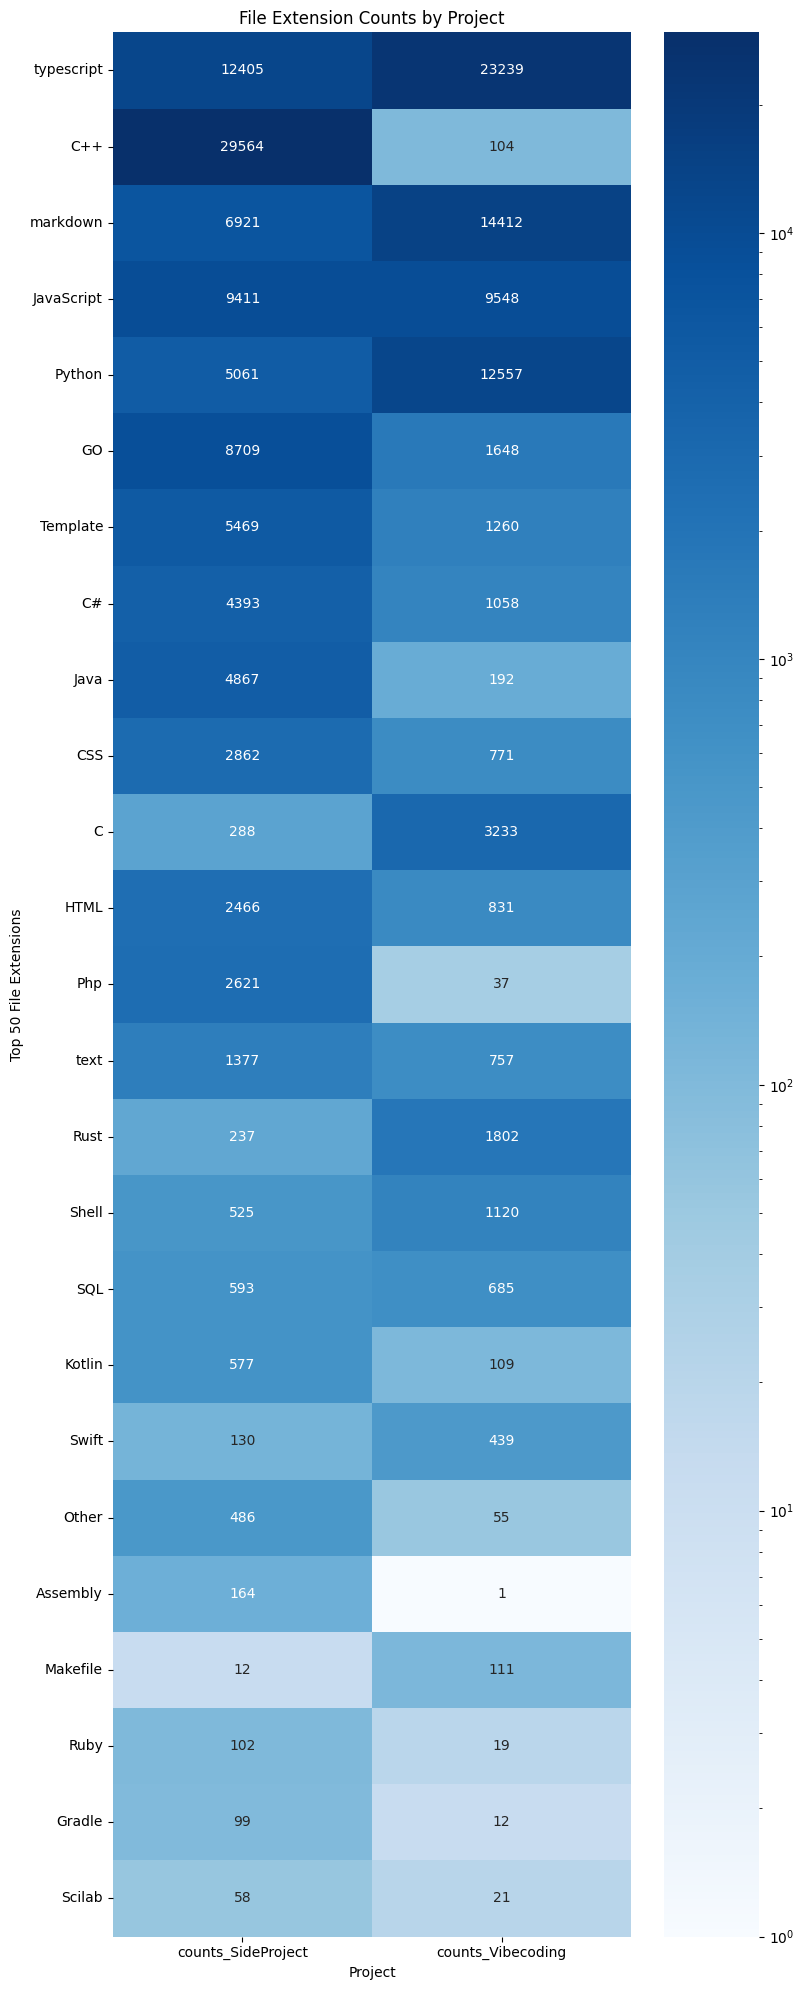

In [ ]:
plt.figure(figsize=(8, 20))
sns.heatmap(
heatmap_data[:25],
annot=True,
fmt=".0f",
cmap="Blues",
norm=LogNorm(vmin=max(1, heatmap_data[heatmap_data > 0].min().min()),
                vmax=heatmap_data.max().max())
)
plt.title("File Extension Counts by Project")
plt.xlabel("Project")
plt.ylabel("Top 50 File Extensions")
plt.tight_layout()
plt.show()

## Distributions

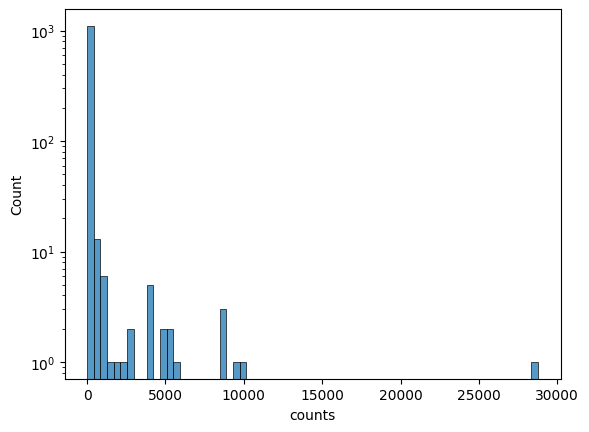

In [ ]:
extn_count = df_sp['extn'].value_counts().rename_axis("extn").reset_index(name='counts')


plot = sns.histplot(extn_count, x="counts", log=True)

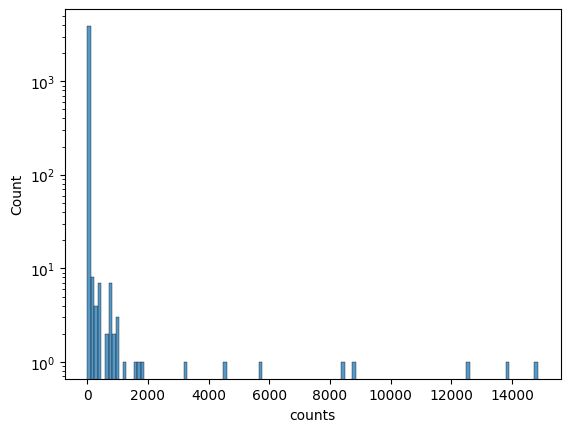

In [ ]:
extn_count = df_vc['extn'].value_counts().rename_axis("extn").reset_index(name='counts')


plot = sns.histplot(extn_count, x="counts", log=True)

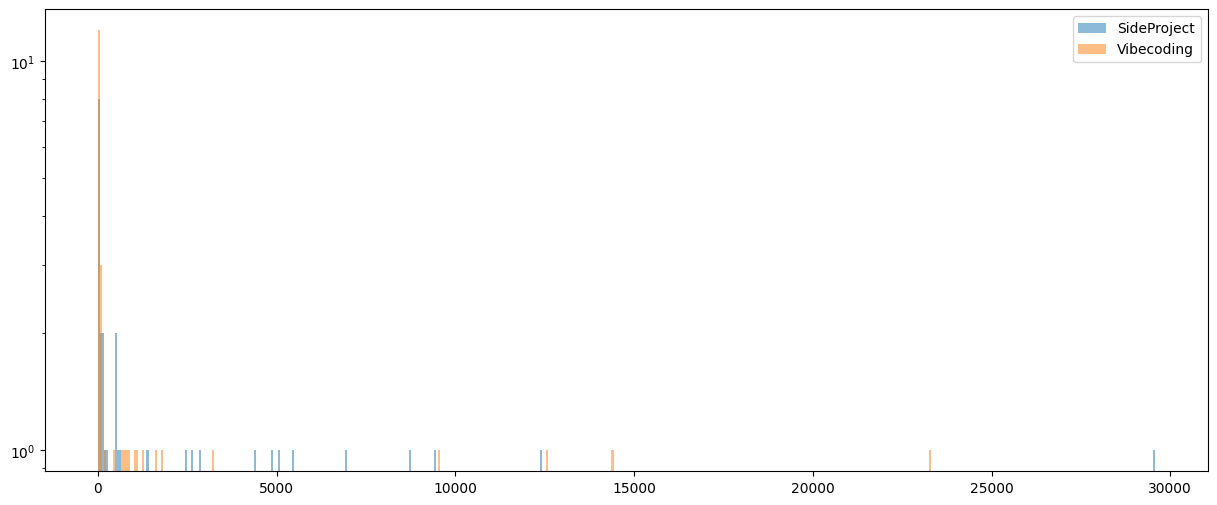

In [ ]:

side = heatmap_data["counts_SideProject"].dropna()
vibe = heatmap_data["counts_Vibecoding"].dropna()

all_vals = np.concatenate([side, vibe])

bins = np.histogram_bin_edges(all_vals, bins=500)

plt.figure(figsize=(15,6))

plt.hist(side, bins=bins, alpha=0.5, label="SideProject", log=True)
plt.hist(vibe, bins=bins, alpha=0.5, label="Vibecoding", log=True)

# plt.xscale("log")
plt.legend()
plt.show()

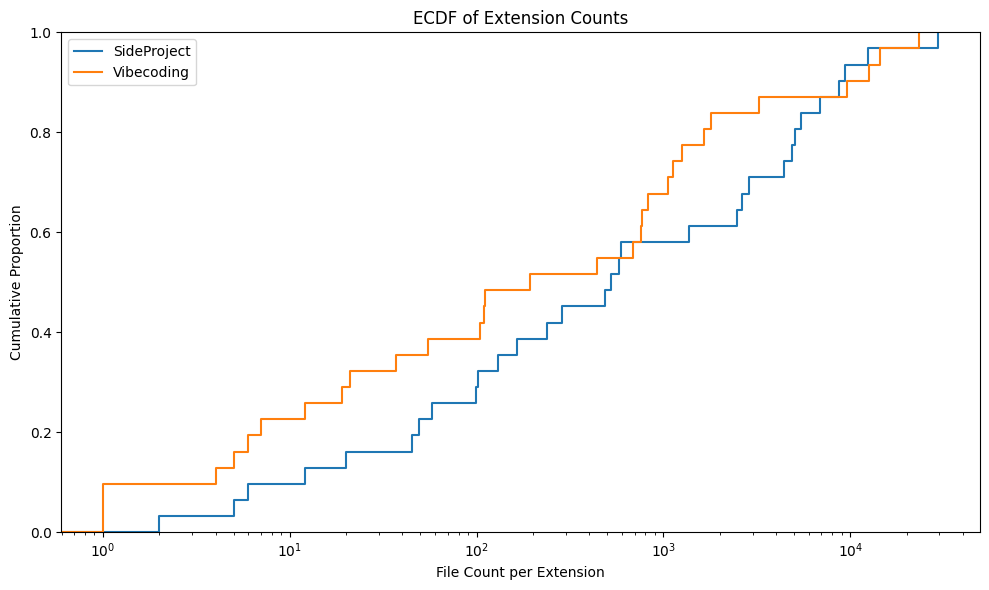

In [ ]:


plt.figure(figsize=(10,6))

sns.ecdfplot(heatmap_data["counts_SideProject"], label="SideProject")
sns.ecdfplot(heatmap_data["counts_Vibecoding"], label="Vibecoding")

plt.xscale("log")
plt.xlabel("File Count per Extension")
plt.ylabel("Cumulative Proportion")
plt.title("ECDF of Extension Counts")
plt.legend()
plt.tight_layout()
plt.show()

## Concentration of extensions per project

In [ ]:
extn_count_sp = df_sp['extn'].value_counts().rename_axis("extn").reset_index(name='counts')
extn_count_vc = df_vc['extn'].value_counts().rename_axis("extn").reset_index(name='counts')

In [ ]:
df_sp["source"] = "SideProject"
df_vc["source"] = "Vibecoding"

df_all = pd.concat([df_sp, df_vc], ignore_index=True)
df_all.head()

,Unnamed: 0,url,proj_name,full_path,file_name,extn,lines,blank_lines,n_characters,avg_char_line,extn_flt,source
0,0,https://github.com/Skowt/Loadr,Loadr,Loadr/README.md,README.md,md,30,7,1038.0,45.130435,markdown,SideProject
1,1,https://github.com/Skowt/Loadr,Loadr,Loadr/manifest.json,manifest.json,json,21,0,896.0,42.666667,json,SideProject
2,2,https://github.com/Skowt/Loadr,Loadr,Loadr/options.html,options.html,html,153,36,4458.0,38.102564,HTML,SideProject
3,3,https://github.com/Skowt/Loadr,Loadr,Loadr/css/bootstrap.min.css,bootstrap.min.css,css,5,0,112578.0,22515.600000,CSS,SideProject
4,4,https://github.com/Skowt/Loadr,Loadr,Loadr/css/bootstrap-responsive.css,bootstrap-responsive.css,css,1109,21,16864.0,15.500000,CSS,SideProject


In [ ]:
counts = (
    df_all
    .groupby(["source", "url", "extn"])
    .size()
    .reset_index(name="n_files")
)

In [ ]:
extn = "py"
plot_df = counts[counts["extn"] == extn]
sp_df= plot_df[plot_df["source"] == "SideProject"]
vc_df= plot_df[plot_df["source"] == "Vibecoding"]

print(f"total {extn}: \t{len(plot_df)}")
print(f"SideProject {extn}:\t {len(sp_df)}")
print(f"Vibecoding {extn}:\t {len(vc_df)}")

total py: 	322
SideProject py:	 152
Vibecoding py:	 170


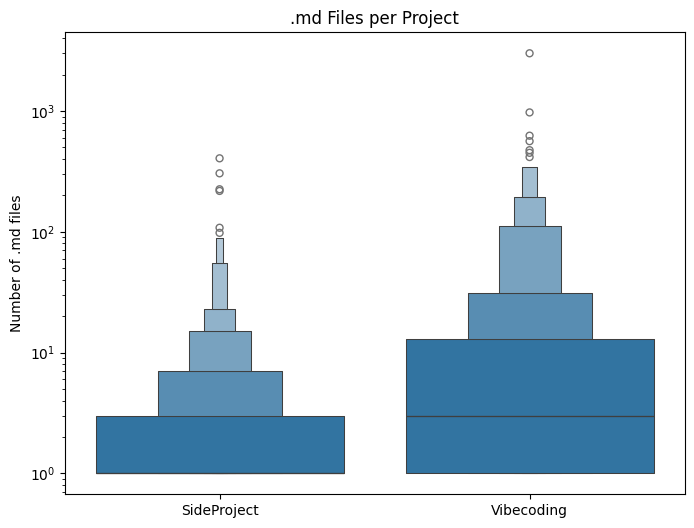

In [ ]:
extn = "py"

plot_df = counts[counts["extn"] == extn]


plt.figure(figsize=(8,6))
sns.boxenplot(
    data=plot_df,
    x="source",
    y="n_files",
    log_scale=True
)

plt.title(f".{extn} Files per Project")
plt.ylabel(f"Number of .{extn} files")
plt.xlabel("")
plt.show()

## Number of files per project

In [ ]:
extn_count_sp = df_sp['extn'].value_counts().rename_axis("extn").reset_index(name='counts')
extn_count_vc = df_vc['extn'].value_counts().rename_axis("extn").reset_index(name='counts')
df_sp["source"] = "SideProject"
df_vc["source"] = "Vibecoding"

df_all = pd.concat([df_sp, df_vc], ignore_index=True)
df_all.head()

,Unnamed: 0,url,proj_name,full_path,file_name,extn,lines,blank_lines,n_characters,avg_char_line,extn_flt,source
0,0,https://github.com/Skowt/Loadr,Loadr,Loadr/README.md,README.md,md,30,7,1038.0,45.130435,markdown,SideProject
1,1,https://github.com/Skowt/Loadr,Loadr,Loadr/manifest.json,manifest.json,json,21,0,896.0,42.666667,json,SideProject
2,2,https://github.com/Skowt/Loadr,Loadr,Loadr/options.html,options.html,html,153,36,4458.0,38.102564,HTML,SideProject
3,3,https://github.com/Skowt/Loadr,Loadr,Loadr/css/bootstrap.min.css,bootstrap.min.css,css,5,0,112578.0,22515.600000,CSS,SideProject
4,4,https://github.com/Skowt/Loadr,Loadr,Loadr/css/bootstrap-responsive.css,bootstrap-responsive.css,css,1109,21,16864.0,15.500000,CSS,SideProject


In [ ]:
counts = (
    df_all
    .groupby([ "url", "source"])
    .size()
    .reset_index(name="n_files")
)
counts.head()

,url,source,n_files
0,https://github.com/007rudra007/hangar,Vibecoding,103
1,https://github.com/10xuio/aiseo,Vibecoding,192
2,https://github.com/1337hero/yeet,Vibecoding,47
3,https://github.com/13pathak/AI-Popup-Infopedia,Vibecoding,30
4,https://github.com/2018kguo/RobinhoodBot,SideProject,33


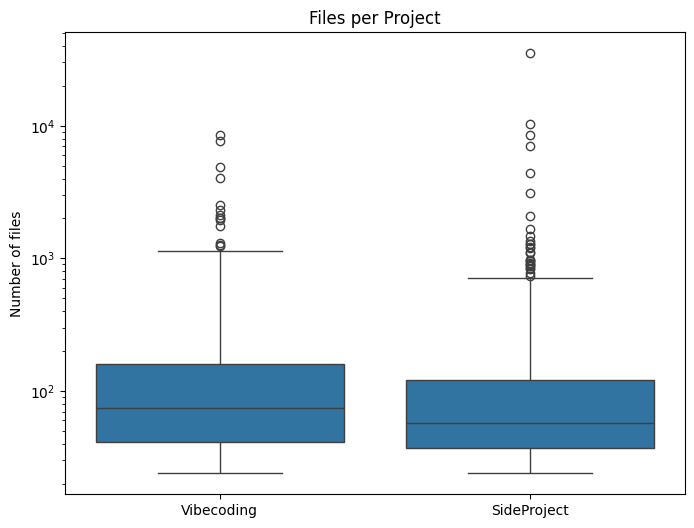

In [ ]:

#plot_df = counts[counts["extn"] == extn]

plt.figure(figsize=(8,6))
sns.boxplot(
    data=counts,
    x="source",
    y="n_files",
    log_scale=True
)

plt.title(f"Files per Project")
plt.ylabel("Number of files")
plt.xlabel("")
plt.show()

## Project size plotted by age

In [ ]:
counts = (
    df_all
    .groupby([ "url", "source"])
    .size()
    .reset_index(name="n_files")
)
counts.head()

,url,source,n_files
0,https://github.com/007rudra007/hangar,Vibecoding,103
1,https://github.com/10xuio/aiseo,Vibecoding,192
2,https://github.com/1337hero/yeet,Vibecoding,47
3,https://github.com/13pathak/AI-Popup-Infopedia,Vibecoding,30
4,https://github.com/2018kguo/RobinhoodBot,SideProject,33


In [ ]:
project_age = pd.read_csv("../dataset_features/project_age.csv")

In [ ]:
project_age.columns

Index(['url', ' age'], dtype='str')

In [ ]:
project_age[" age"]

https://github.com/Skowt/Loadr                     {'repo': 'Skowt/Loadr'                     'created_at': datetime.datetime(2014  11  27  8   25  57  tzinfo=datetime.timezone.utc)  'target_date': datetime.datetime(2022  8   2   19  51  39     'age_days': 2805}
https://github.com/AI-Spawn/Save-The-Turtles       {'repo': 'AI-Spawn/Save-The-Turtles'       'created_at': datetime.datetime(2021  10  21  20  44  2   tzinfo=datetime.timezone.utc)  'target_date': datetime.datetime(2021  10  26  0   54  10        'age_days': 4}
https://github.com/YigitGunduc/cycle               {'repo': 'YigitGunduc/cycle'               'created_at': datetime.datetime(2021  11  12  13  26  48  tzinfo=datetime.timezone.utc)  'target_date': datetime.datetime(2021  11  17  9   6   53        'age_days': 4}
https://github.com/saurabh0719/jett                {'repo': 'saurabh0719/jett'                'created_at': datetime.datetime(2022  9   18  5   31  3   tzinfo=datetime.timezone.utc)  'target_date': datetime.date

In [ ]:
project_age['days'] = project_age[' age'].str.extract(r"'age_days':\s*(\d+)")

In [ ]:
import re
pattern = r'^https?://github\.com/[^,\s]+'

In [ ]:

project_age["url_source"] =[re.search(pattern, i[0]).group(0)  for i in project_age.index]

In [ ]:
project_age.head()

,,,,,,,,,,,,,,,url,age,days,url_source
https://github.com/Skowt/Loadr,{'repo': 'Skowt/Loadr','created_at': datetime.datetime(2014,11,27,8,25,57,tzinfo=datetime.timezone.utc),'target_date': datetime.datetime(2022,8,2,19,51,39,tzinfo=datetime.timezone.utc),'age_days': 2805},2805,https://github.com/Skowt/Loadr
https://github.com/AI-Spawn/Save-The-Turtles,{'repo': 'AI-Spawn/Save-The-Turtles','created_at': datetime.datetime(2021,10,21,20,44,2,tzinfo=datetime.timezone.utc),'target_date': datetime.datetime(2021,10,26,0,54,10,tzinfo=datetime.timezone.utc),'age_days': 4},4,https://github.com/AI-Spawn/Save-The-Turtles
https://github.com/YigitGunduc/cycle,{'repo': 'YigitGunduc/cycle','created_at': datetime.datetime(2021,11,12,13,26,48,tzinfo=datetime.timezone.utc),'target_date': datetime.datetime(2021,11,17,9,6,53,tzinfo=datetime.timezone.utc),'age_days': 4},4,https://github.com/YigitGunduc/cycle
https://github.com/saurabh0719/jett,{'repo': 'saurabh0719/jett','created_at': datetime.datetime(2022,9,18,5,31,3,tzinfo=datetime.timezone.utc),'target_date': datetime.datetime(2022,9,23,13,2,53,tzinfo=datetime.timezone.utc),'age_days': 5},5,https://github.com/saurabh0719/jett
https://github.com/tn/climood,{'repo': 'tn/climood','created_at': datetime.datetime(2021,9,23,22,1,31,tzinfo=datetime.timezone.utc),'target_date': datetime.datetime(2021,9,23,22,23,42,tzinfo=datetime.timezone.utc),'age_days': 0},0,https://github.com/tn/climood


In [ ]:
project_age.index

MultiIndex([(                             'https://github.com/Skowt/Loadr', ...),
            (               'https://github.com/AI-Spawn/Save-The-Turtles', ...),
            (                       'https://github.com/YigitGunduc/cycle', ...),
            (                        'https://github.com/saurabh0719/jett', ...),
            (                              'https://github.com/tn/climood', ...),
            (     'https://github.com/PaulVLAD22/Wikipedia-Text-Formatter', ...),
            (                     'https://github.com/tibordp/coinflipper', ...),
            (       'https://github.com/Mikescops/gitlab-notify-extension', ...),
            (               'https://github.com/Etheonor/supanextail-lite', ...),
            (                         'https://github.com/murfffi/zebra4j', ...),
            ...
            (              'https://github.com/Ami3466/ai-live-log-bridge', ...),
            (                    'https://github.com/imabeastdrew/resybot', ...),


In [ ]:
size_age = counts.merge(project_age, left_on="url", right_on="url_source", how='inner')

In [ ]:
size_age.head()

,url_x,source,n_files,url_y,age,days,url_source
0,https://github.com/007rudra007/hangar,Vibecoding,103,tzinfo=datetime.timezone.utc),'age_days': 0},0,https://github.com/007rudra007/hangar
1,https://github.com/10xuio/aiseo,Vibecoding,192,tzinfo=datetime.timezone.utc),'age_days': 16},16,https://github.com/10xuio/aiseo
2,https://github.com/1337hero/yeet,Vibecoding,47,tzinfo=datetime.timezone.utc),'age_days': 67},67,https://github.com/1337hero/yeet
3,https://github.com/13pathak/AI-Popup-Infopedia,Vibecoding,30,tzinfo=datetime.timezone.utc),'age_days': 139},139,https://github.com/13pathak/AI-Popup-Infopedia
4,https://github.com/2018kguo/RobinhoodBot,SideProject,33,tzinfo=datetime.timezone.utc),'age_days': 739},739,https://github.com/2018kguo/RobinhoodBot


In [ ]:
size_age["days"] = size_age["days"].fillna(-1).astype(int)

In [ ]:
print(size_age["source"].value_counts())

source
SideProject    672
Vibecoding     436
Name: count, dtype: int64


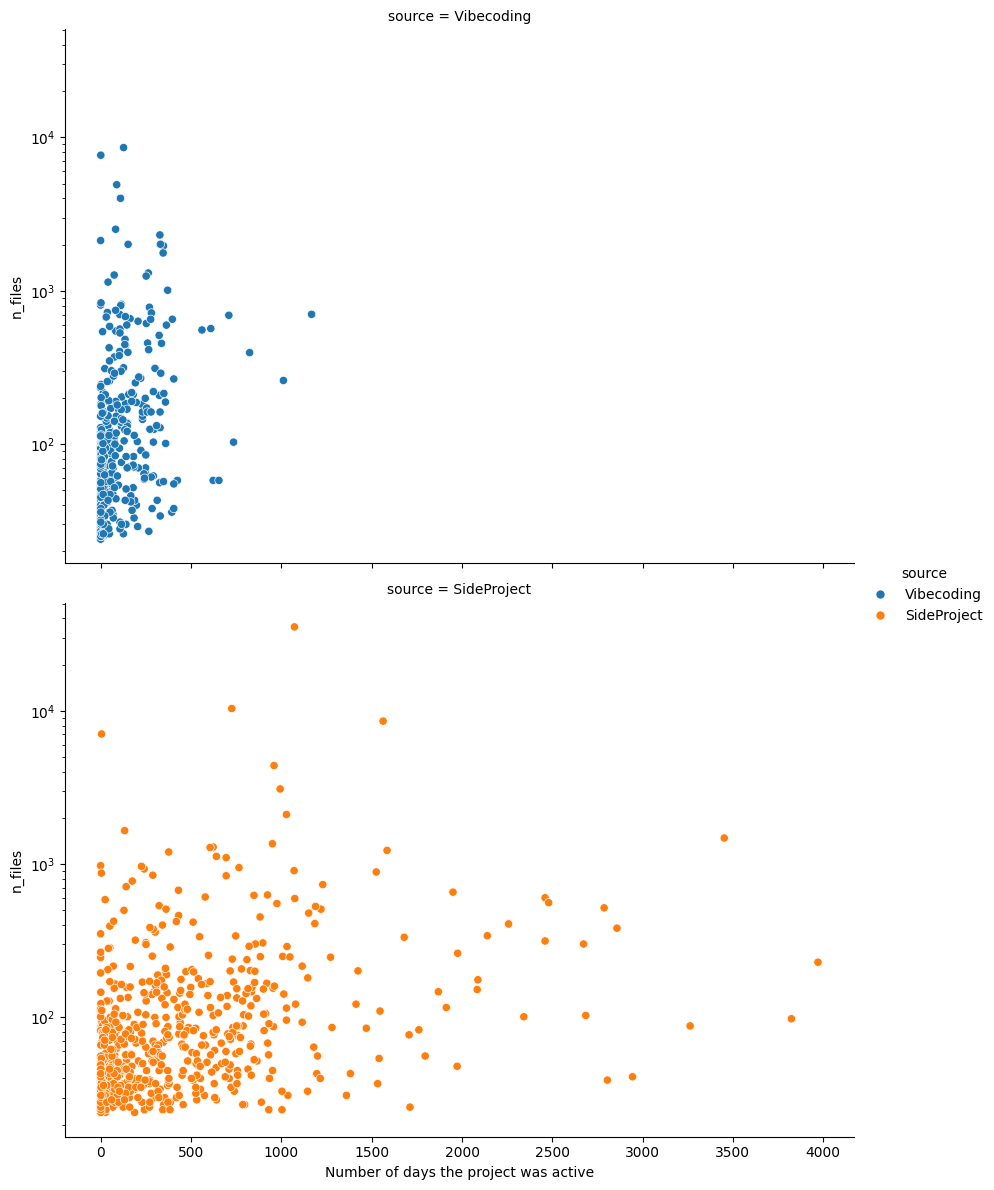

In [ ]:
g = sns.relplot(
    data=size_age,
    x="days",
    y="n_files",
    row="source",        # splits into separate plots
    kind="scatter",
    height=6,
    aspect=1.5,
    hue="source"
)
g.set_xlabels("Number of days the project was active")
g.set(yscale="log")


In [ ]:
filt_size_age = size_age[(size_age['n_files'] > -1) ] # & (size_age['n_files'] < 20000)
filt_size_age = filt_size_age[(filt_size_age['days'] > 0) & (filt_size_age['days'] < 417)] #
print(filt_size_age["source"].value_counts())

n = filt_size_age["source"].value_counts().min()

df_balanced = (
    pd.concat(
        [
            group.sample(n=n, random_state=42)
            for _, group in filt_size_age.groupby("source")
        ],
        ignore_index=True
    )
)

print(df_balanced["source"].value_counts())

source
SideProject    364
Vibecoding     329
Name: count, dtype: int64
source
SideProject    329
Vibecoding     329
Name: count, dtype: int64


In [ ]:
size_age.head()

,url_x,source,n_files,url_y,age,days,url_source
0,https://github.com/007rudra007/hangar,Vibecoding,103,tzinfo=datetime.timezone.utc),'age_days': 0},0,https://github.com/007rudra007/hangar
1,https://github.com/10xuio/aiseo,Vibecoding,192,tzinfo=datetime.timezone.utc),'age_days': 16},16,https://github.com/10xuio/aiseo
2,https://github.com/1337hero/yeet,Vibecoding,47,tzinfo=datetime.timezone.utc),'age_days': 67},67,https://github.com/1337hero/yeet
3,https://github.com/13pathak/AI-Popup-Infopedia,Vibecoding,30,tzinfo=datetime.timezone.utc),'age_days': 139},139,https://github.com/13pathak/AI-Popup-Infopedia
4,https://github.com/2018kguo/RobinhoodBot,SideProject,33,tzinfo=datetime.timezone.utc),'age_days': 739},739,https://github.com/2018kguo/RobinhoodBot


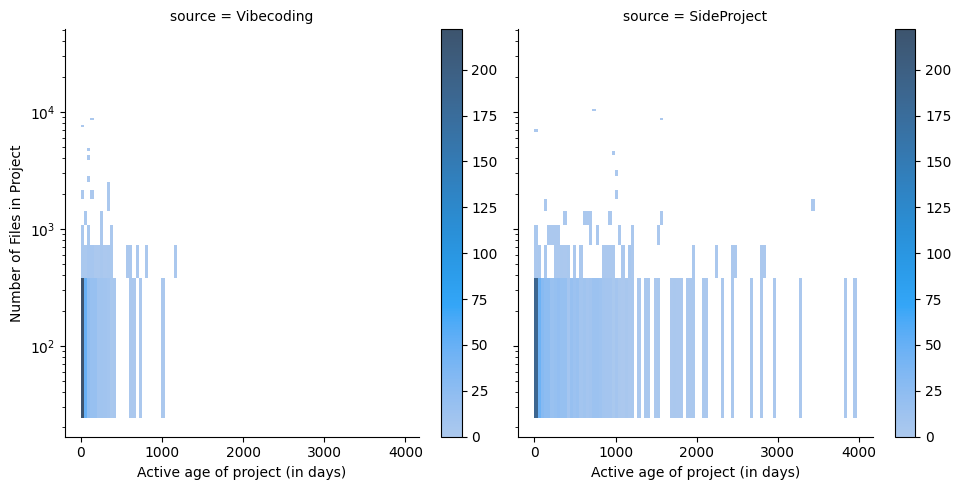

In [ ]:

g = sns.displot(
    data=size_age,
    x="days",
    y="n_files",
    col="source",
    kind="hist",
    # hue="source",
    bins=100,
    cbar=True,
    # palette="rocket",
    common_norm=LogNorm
    # common_norm=LogNorm(vmin=size_age[size_age["n_files"] > 0].min().min(),
    #             vmax=size_age["n_files"].max().max()),

)
g.set_xlabels("Active age of project (in days)")
g.set_ylabels("Number of Files in Project")
g.set(yscale="log")
# g.set(xscale="log")

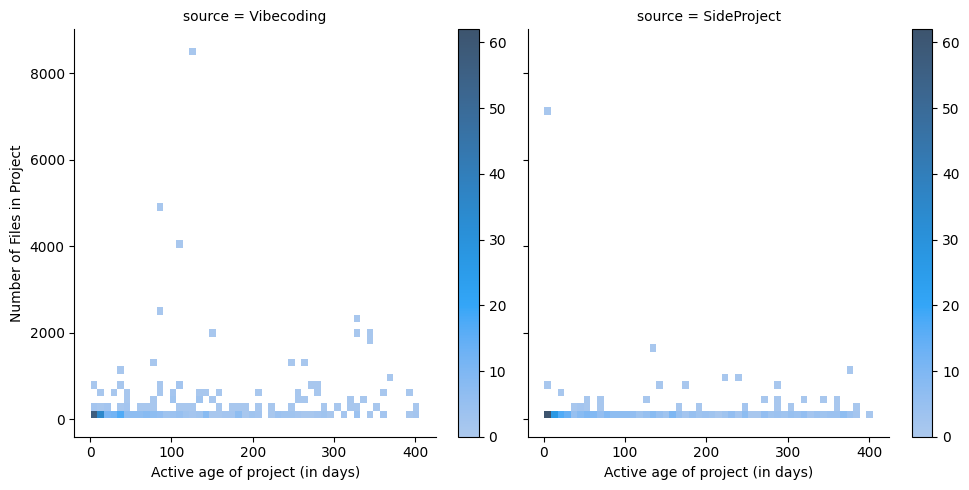

In [ ]:
g = sns.displot(
    data=filt_size_age,
    x="days",
    y="n_files",
    col="source",
    kind="hist",
    # hue="source",
    bins=50,
    cbar=True,
    # palette="rocket",
    # common_norm=LogNorm(vmin=filt_size_age[filt_size_age > 0].min().min(),
    #             vmax=filt_size_age.max().max()),

)
g.set_xlabels("Active age of project (in days)")
g.set_ylabels("Number of Files in Project")
# g.set(yscale="log")
# g.set(xscale="log")

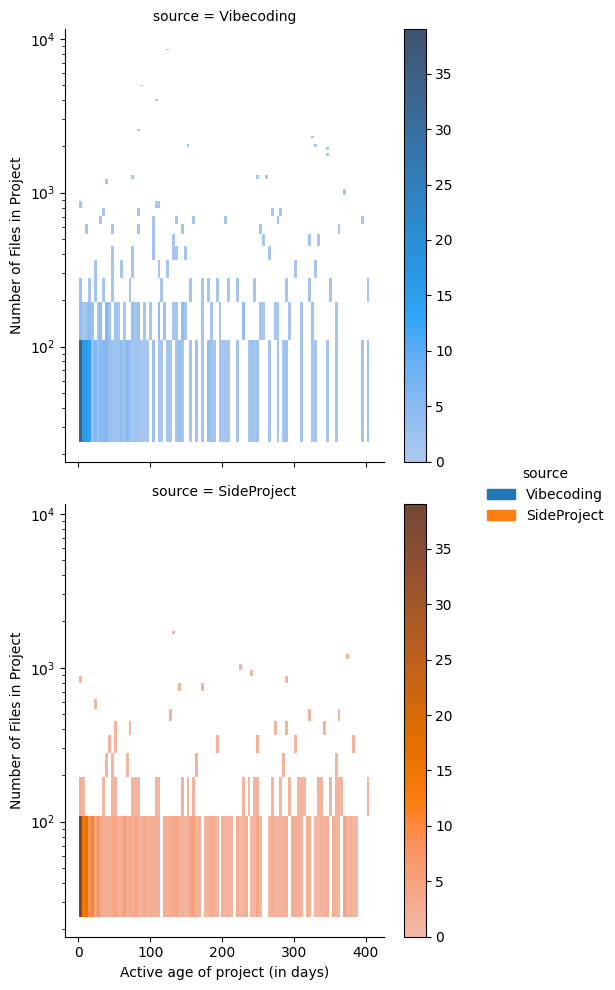

In [ ]:
g = sns.displot(
    data=df_balanced,
    x="days",
    y="n_files",
    row="source",
    row_order=[ "Vibecoding", "SideProject"],
    kind="hist",
    hue="source",
    hue_order=[ "Vibecoding", "SideProject"],
    bins=100,
    cbar=True,
    # palette="rocket",
    # common_norm=LogNorm(vmin=filt_size_age[filt_size_age > 0].min().min(),
    #             vmax=filt_size_age.max().max()),

)
g.set_xlabels("Active age of project (in days)")
g.set_ylabels("Number of Files in Project")
g.set(yscale="log")
# g.set(xscale="log")

## frequencey of files per project

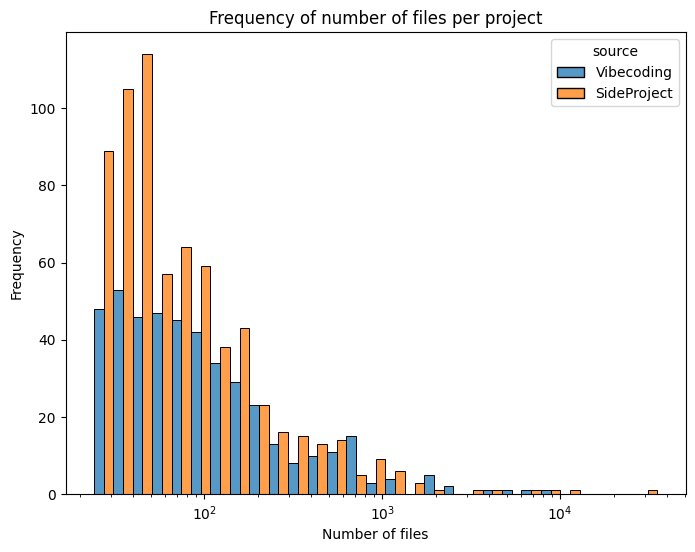

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(
    data=counts,
    x="n_files",
    hue="source", 
    multiple="dodge",
    log_scale=True
)
plt.xscale("log")
plt.title(f"Frequency of number of files per project")
plt.ylabel("Frequency")
plt.xlabel("Number of files")
plt.show()

<Axes: xlabel='n_files', ylabel='Proportion'>

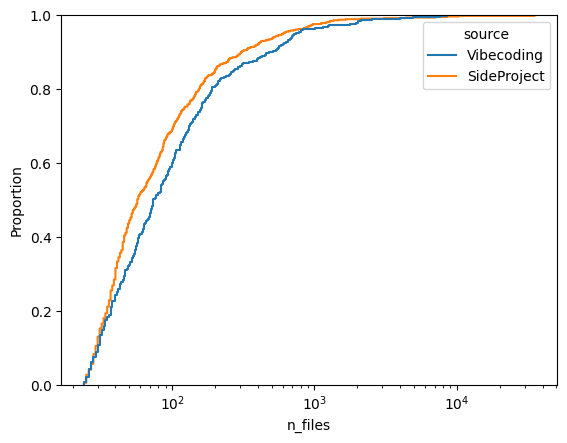

In [ ]:
sns.ecdfplot(data=counts,
    x="n_files",
    hue="source", stat="proportion", log_scale=True)

In [ ]:
counts_filt = counts[(counts['n_files'] > 10000) ]#& (counts['n_files'] < 10000)]
counts_filt #.groupby(["source"]).n_files.max()

,url,source,n_files
494,https://github.com/croma-app/croma-react,SideProject,35204
565,https://github.com/fayazara/fluenticons,SideProject,10337


## Number of projects that have at least one file of a given language

In [ ]:
print(df_all.head())
print(df_all["source"][int(df_all.index[df_all.proj_name == "Anubis"].max())])
print(df_all["source"][int(df_all.index[df_all.proj_name == "Ben-s-Software-"].max())])

  Unnamed: 0                             url proj_name  \
0          0  https://github.com/Skowt/Loadr     Loadr   
1          1  https://github.com/Skowt/Loadr     Loadr   
2          2  https://github.com/Skowt/Loadr     Loadr   
3          3  https://github.com/Skowt/Loadr     Loadr   
4          4  https://github.com/Skowt/Loadr     Loadr   

                            full_path                 file_name  extn  lines  \
0                     Loadr/README.md                 README.md    md     30   
1                 Loadr/manifest.json             manifest.json  json     21   
2                  Loadr/options.html              options.html  html    153   
3         Loadr/css/bootstrap.min.css         bootstrap.min.css   css      5   
4  Loadr/css/bootstrap-responsive.css  bootstrap-responsive.css   css   1109   

   blank_lines  n_characters  avg_char_line  extn_flt       source  
0            7        1038.0      45.130435  markdown  SideProject  
1            0         896.0    

In [ ]:
df_groups = df_all.groupby(["extn", "url", "source"]).size().reset_index(name="n_files")
df_group_counts = df_groups.groupby(['extn',"source"]).size()

In [ ]:
df_group_counts.head() #= pd.DataFrame(df_group_counts)


extn                                        source     
 -n 3  cat                                 Vibecoding     1
$CACHE_FILE$                                SideProject    1
, news API integration, and testing setup  Vibecoding     1
0                                           Vibecoding     3
012v                                        Vibecoding     1
dtype: int64

In [ ]:
heatmap_df = df_group_counts.unstack(fill_value=0).reset_index(names="extn")
print(heatmap_df.columns)
heatmap_df["sum"] = heatmap_df["SideProject"] + heatmap_df["Vibecoding"]
heatmap_df=  heatmap_df[heatmap_df["extn"].isin(lang_list)]
heatmap_df =heatmap_df.sort_values(by = ["sum"], ascending = False) 
heatmap_df= heatmap_df.set_index("extn")
heatmap_df.head()

Index(['extn', 'SideProject', 'Vibecoding'], dtype='str', name='source')


source,SideProject,Vibecoding,sum
extn,,,
md,672,438,1110
js,386,211,597
html,300,196,496
css,279,192,471
txt,268,181,449


In [ ]:
heatmap_df.drop('sum', axis=1)
heatmap_df["SideProject"] = heatmap_df["SideProject"]/690
heatmap_df["Vibecoding"] = heatmap_df["Vibecoding"]/456 

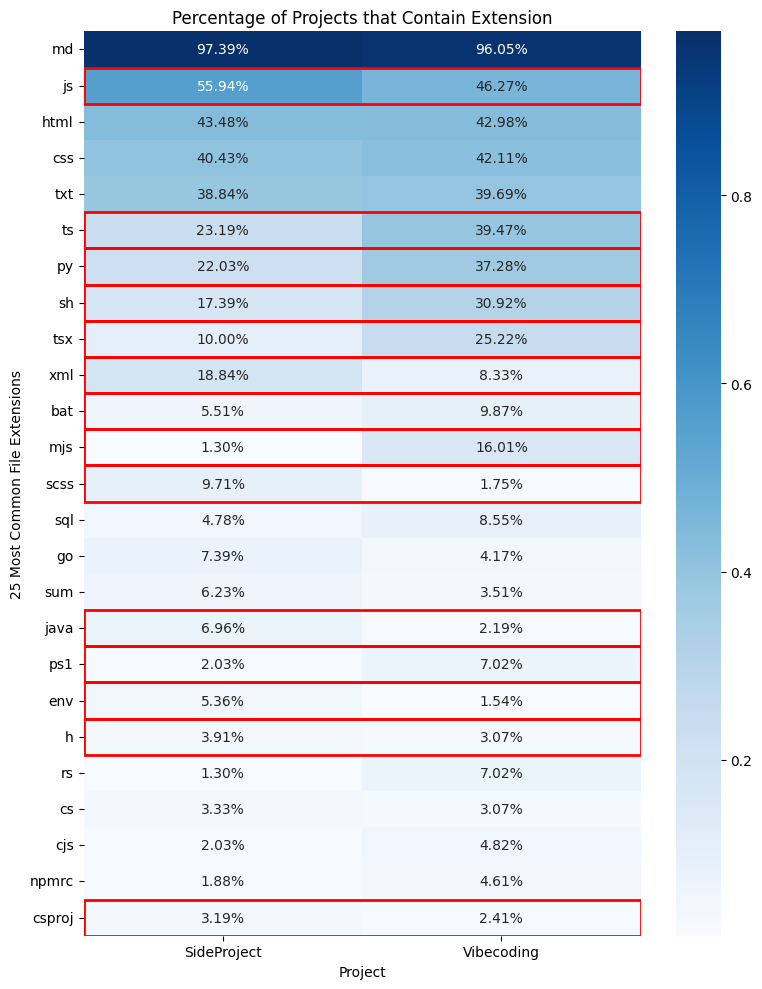

In [ ]:
df = heatmap_df.drop('sum', axis=1)

plt.figure(figsize=(8, 10))
ax = sns.heatmap(
    df[:25],
    annot=True,
    fmt=".2%",
    cmap="Blues"
)

# Example: box around rows 2–5 (0-indexed)
box_color = 'red'
box_line = 2
row = 11
rect_mjs = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 8
rect_tsx = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 5
rect_ts = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 6
rect_py = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 12
rect_scss = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 7
rect_sh = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 19
rect_rs = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)
row = 9
rect_xml = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 17
rect_ps1 = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 24
rect_gradle = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 16
rect_java = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)
row = 18
rect_env = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 1
rect_js = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)

row = 10
rect_bat = patches.Rectangle(
    (0, row),                 # (x, y)
    width=df.shape[1],              # full width
    height= 1, # number of rows
    linewidth=box_line,
    edgecolor=box_color,
    facecolor='none'
)


ax.add_patch(rect_mjs)
ax.add_patch(rect_tsx)
ax.add_patch(rect_ts)
ax.add_patch(rect_py)
ax.add_patch(rect_scss)
ax.add_patch(rect_sh)
ax.add_patch(rect_rs)
ax.add_patch(rect_xml)
ax.add_patch(rect_ps1)
ax.add_patch(rect_gradle)
ax.add_patch(rect_java)
ax.add_patch(rect_env)
ax.add_patch(rect_js)
ax.add_patch(rect_bat)

plt.title("Percentage of Projects that Contain Extension")
plt.xlabel("Project")
plt.ylabel("25 Most Common File Extensions")
plt.tight_layout()
plt.show()


### Finding all projects that have that extension as the main extension

In [ ]:
df_groups = df_all.groupby(["extn", "url", "source"]).size().reset_index(name="n_files")
df_groups =  df_groups[df_groups["extn"].isin(lang_list)]
df_groups.head()

,extn,url,source,n_files
2654,asm,https://github.com/HarelZeevi/Missile_Command,SideProject,1
2655,asm,https://github.com/Suwot/ffmpeg,Vibecoding,161
2656,asm,https://github.com/croma-app/croma-react,SideProject,15
2662,astro,https://github.com/Wirasm/astro-comp-lib,Vibecoding,45
2663,astro,https://github.com/brainless/brainless.in,Vibecoding,16


In [ ]:
df_top = df_groups.groupby("url").max()
print(df_top.head())
#print(df_top["extn"].value_counts())
df_top_groups = df_top.groupby(['extn',"source"]).size()

heatmap_df = df_top_groups.unstack(fill_value=0).reset_index(names="extn")
heatmap_df["sum"] = heatmap_df["SideProject"] + heatmap_df["Vibecoding"]
heatmap_df = heatmap_df.sort_values(by = ["sum"], ascending = False) 
heatmap_df = heatmap_df.drop('sum', axis=1)
heatmap_df["SideProject"] = heatmap_df["SideProject"]/690
heatmap_df["Vibecoding"] = heatmap_df["Vibecoding"]/456 
heatmap_df

                                               extn       source  n_files
url                                                                      
https://github.com/007rudra007/hangar           xml   Vibecoding       18
https://github.com/10xuio/aiseo                 tsx   Vibecoding       95
https://github.com/1337hero/yeet                 rs   Vibecoding        6
https://github.com/13pathak/AI-Popup-Infopedia   md   Vibecoding        3
https://github.com/2018kguo/RobinhoodBot        txt  SideProject        3


source,extn,SideProject,Vibecoding
24,txt,0.281159,0.335526
2,md,0.200000,0.144737
28,xml,0.182609,0.083333
22,ts,0.088406,0.087719
23,tsx,0.047826,0.133772
17,sh,0.033333,0.070175
10,py,0.042029,0.050439
20,sum,0.031884,0.010965
21,swift,0.005797,0.013158
7,php,0.011594,0.004386


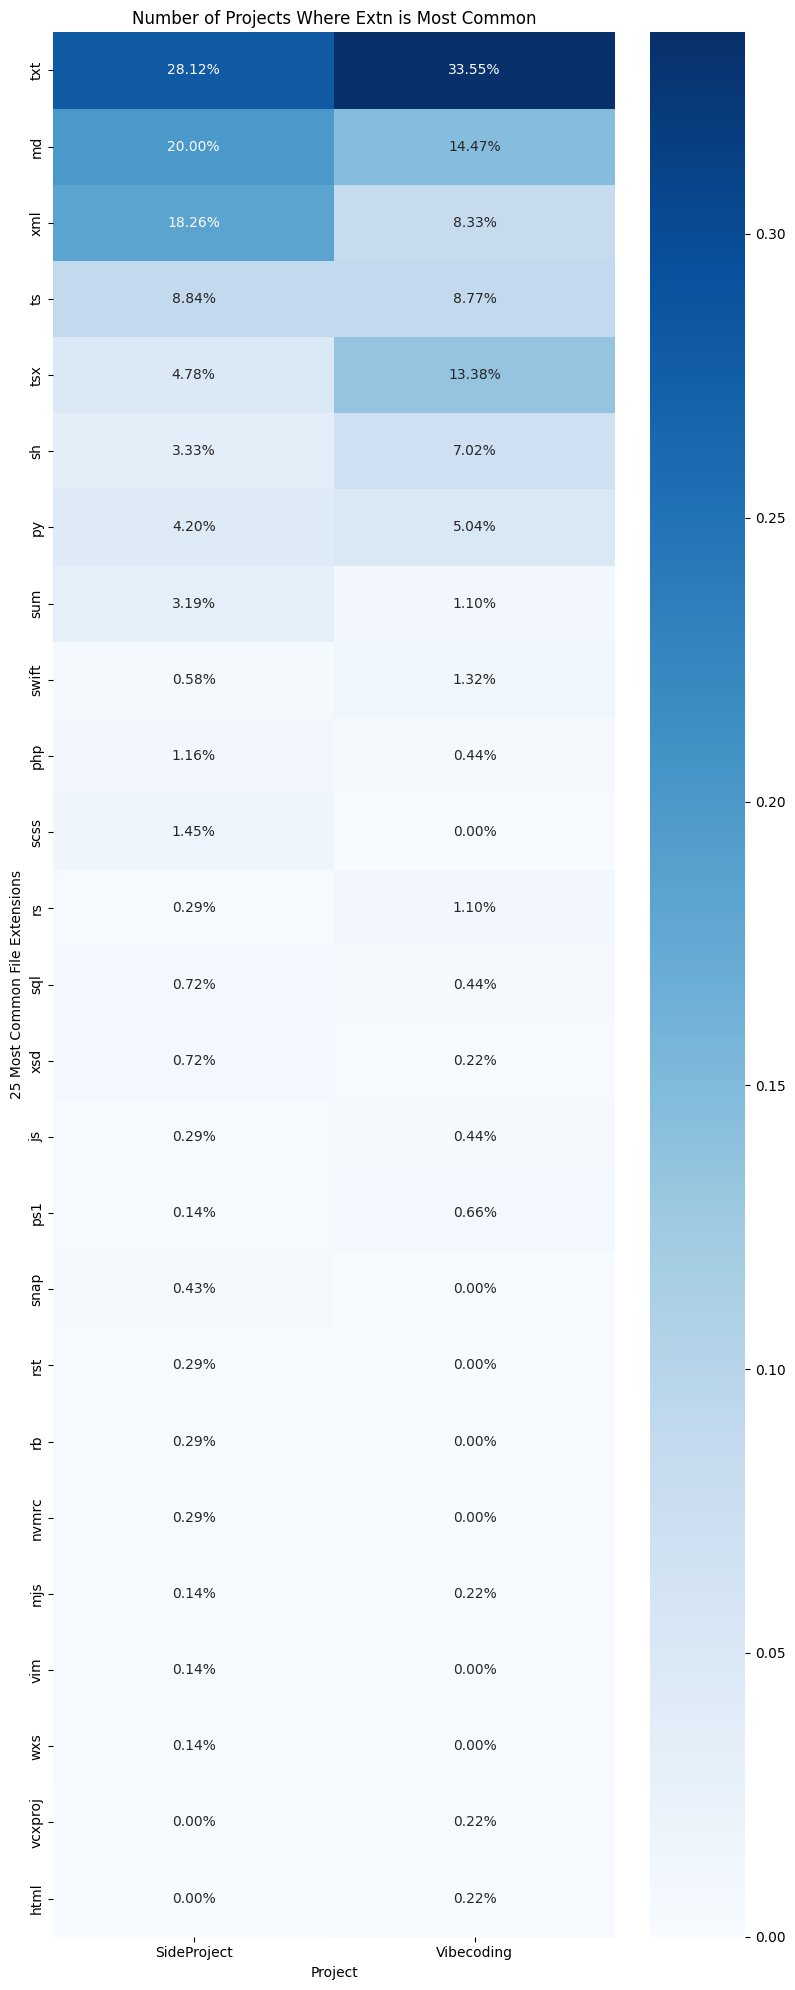

In [ ]:
df = heatmap_df.set_index("extn")
plt.figure(figsize=(8, 20))
sns.heatmap(
df[:25],
annot=True,
fmt=".2%",
cmap="Blues",
# norm=LogNorm(vmin=max(1, df[df > 0].min().min()),
#                 vmax=df.max().max())
)
plt.title("Number of Projects Where Extn is Most Common")
plt.xlabel("Project")
plt.ylabel("25 Most Common File Extensions")
plt.tight_layout()
plt.show()

For txt/markdown, list those projects and go through them
Understand how the distributions of number of files

Also turn has an extension into a giant boolean table and do some statistical tests

Sample table:

        extn 1  extn 2  extn3

url 1   true    false   true

url 2   false   true    true

url 3   true    false   false

### Undertanding .txt

In [ ]:
df_all.head()

,Unnamed: 0,url,proj_name,full_path,file_name,extn,lines,blank_lines,n_characters,avg_char_line,extn_flt,source
0,0,https://github.com/Skowt/Loadr,Loadr,Loadr/README.md,README.md,md,30,7,1038.0,45.130435,markdown,SideProject
1,1,https://github.com/Skowt/Loadr,Loadr,Loadr/manifest.json,manifest.json,json,21,0,896.0,42.666667,json,SideProject
2,2,https://github.com/Skowt/Loadr,Loadr,Loadr/options.html,options.html,html,153,36,4458.0,38.102564,HTML,SideProject
3,3,https://github.com/Skowt/Loadr,Loadr,Loadr/css/bootstrap.min.css,bootstrap.min.css,css,5,0,112578.0,22515.600000,CSS,SideProject
4,4,https://github.com/Skowt/Loadr,Loadr,Loadr/css/bootstrap-responsive.css,bootstrap-responsive.css,css,1109,21,16864.0,15.500000,CSS,SideProject


In [ ]:
df_groups = df_all.groupby(["extn", "url", "source"]).size().reset_index(name="n_files")
df_top = df_groups.groupby("url").extn.max()
df_groups.head()

,extn,url,source,n_files
0,-n 3  cat,https://github.com/Kabi10/ratemyemployer,Vibecoding,1
1,$CACHE_FILE$,https://github.com/MegaTKC/multiplayer-game,SideProject,1
2,", news API integration, and testing setup",https://github.com/Kabi10/ratemyemployer,Vibecoding,1
3,0,https://github.com/Suwot/ffmpeg,Vibecoding,1
4,0,https://github.com/yagizdas/phi-delta,Vibecoding,1


In [ ]:
df_top.head()

url
https://github.com/007rudra007/hangar                yml
https://github.com/10xuio/aiseo                      tsx
https://github.com/1337hero/yeet                     yml
https://github.com/13pathak/AI-Popup-Infopedia    sample
https://github.com/2018kguo/RobinhoodBot             txt
Name: extn, dtype: str

In [ ]:
# df_top = df_groups.groupby("url")
# df_top.head()

df_txt = df_groups[df_groups["extn"] == "txt"]
top_10_txt = df_txt.nlargest(10, 'n_files')

In [ ]:
df_txt.sort_values("n_files", ascending=False)

,extn,url,source,n_files
22555,txt,https://github.com/Novartis/YADA,SideProject,198
22470,txt,https://github.com/AI-Spawn/Save-The-Turtles,SideProject,106
22788,txt,https://github.com/maithilish/scoopi,SideProject,91
22503,txt,https://github.com/Cthomasdesign/ChunkMonk,Vibecoding,66
22685,txt,https://github.com/diamant3/chip-walo,SideProject,62
...,...,...,...,...
22653,txt,https://github.com/brainless/letsorder,Vibecoding,1
22651,txt,https://github.com/booua/smogbar,SideProject,1
22648,txt,https://github.com/bhavitvyamalik/DialogTag,SideProject,1
22647,txt,https://github.com/benbasha/claudeloop,Vibecoding,1


In [ ]:
top_10_txt

,extn,url,source,n_files
22555,txt,https://github.com/Novartis/YADA,SideProject,198
22470,txt,https://github.com/AI-Spawn/Save-The-Turtles,SideProject,106
22788,txt,https://github.com/maithilish/scoopi,SideProject,91
22503,txt,https://github.com/Cthomasdesign/ChunkMonk,Vibecoding,66
22685,txt,https://github.com/diamant3/chip-walo,SideProject,62
22877,txt,https://github.com/streetwriters/notesnook,SideProject,51
22672,txt,https://github.com/covexo/devspace,SideProject,42
22730,txt,https://github.com/hshadab/kinic-api,Vibecoding,41
22548,txt,https://github.com/MotiaDev/motia-examples,Vibecoding,38
22552,txt,https://github.com/Nevin1901/nweather,SideProject,38


In [ ]:
top_10_txt.index

Index([22555, 22470, 22788, 22503, 22685, 22877, 22672, 22730, 22548, 22552], dtype='int64')

## Number of Python Projects

In [ ]:
df_groups = df_all.groupby(["extn", "url", "source"]).size().reset_index(name="n_files")
df_groups =  df_groups[df_groups["extn"].isin(lang_list)]
df_groups.head()

,extn,url,source,n_files
2654,asm,https://github.com/HarelZeevi/Missile_Command,SideProject,1
2655,asm,https://github.com/Suwot/ffmpeg,Vibecoding,161
2656,asm,https://github.com/croma-app/croma-react,SideProject,15
2662,astro,https://github.com/Wirasm/astro-comp-lib,Vibecoding,45
2663,astro,https://github.com/brainless/brainless.in,Vibecoding,16


In [ ]:
df_py = df_groups[df_groups["extn"]== "py"]
df_py.head()

,extn,url,source,n_files
18784,py,https://github.com/2018kguo/RobinhoodBot,SideProject,3
18785,py,https://github.com/AI-Spawn/multiplayer-game-bot,SideProject,1
18786,py,https://github.com/AI-Spawn/ssbm-bot,SideProject,10
18787,py,https://github.com/Adam-Jimenez/auddit,SideProject,12
18788,py,https://github.com/AdarshB7/patcha-engine,Vibecoding,25


In [ ]:
df_py.source.value_counts()

source
Vibecoding     170
SideProject    152
Name: count, dtype: int64

In [ ]:
df_py_sp = df_py[df_py.source == "SideProject"]
df_py_vc = df_py[df_py.source == "Vibecoding"]

print(df_py_sp.n_files.sum())
print(df_py_vc.n_files.sum())

5061
12557


## Number of files in each category

df_groups = df_all.groupby(["extn", "url", "source"]).size().reset_index(name="n_files")
df_groups =  df_groups[df_groups["extn"].isin(lang_list)]
df_groups.head()

In [ ]:
df_groups = df_all.groupby([ "source"]).size().reset_index(name="n_files")
# df_groups =  df_groups[df_groups["extn"].isin(lang_list)]
df_groups.head()

,source,n_files
0,SideProject,157435
1,Vibecoding,103327


# Make Boolean Map per project

In [ ]:
df_groups = df_all.groupby(["extn", "url", "source"]).size().reset_index(name="n_files")
df_groups.head()# df_group_counts = df_groups.groupby(['extn',"source"]).size()

,extn,url,source,n_files
0,-n 3  cat,https://github.com/Kabi10/ratemyemployer,Vibecoding,1
1,$CACHE_FILE$,https://github.com/MegaTKC/multiplayer-game,SideProject,1
2,", news API integration, and testing setup",https://github.com/Kabi10/ratemyemployer,Vibecoding,1
3,0,https://github.com/Suwot/ffmpeg,Vibecoding,1
4,0,https://github.com/yagizdas/phi-delta,Vibecoding,1


In [ ]:

col_list = ['url', 'source', 'ts',  'tsx', 'markdown', 'md', 'mdx',  'xml', 'cs', 'py',  'js', 'mjs',  'cjs',  'ejs',  'rs',  'css', 
             'kt', 'html', 'sh',  'txt',  'sql',  'astro',  'go', 'c', 'cc',  'cpp',  'hpp', 'csproj',  'm',  'h', 
             'rb', 'tmlanguage', 'java', 'swift',  'ru', 'ipynb',  'bat',  'exe',  'kts', 'wasm',  'npmrc',  'nvmrc',  
             'sb',  'snap', 'http', 'ps1',  'php',  'woff2', 'sum', 'mako',  'ino',  'cmd',  'env', 'ahk',  'bash',  
             'erb', 'onnx',  'server', 'skill',  'tpl',  'class',  'mak', 'mk', 'lua', 's', 'dcu', 'less',  'pas',  
             'woff', 'scss', 'pyc', 'dpr', 'inc', 'res',  'resx',  'dproj',  'hex',  'idl',  'pl', 'bm2', 'dak',  
             'gradle',  'ld',  'rst' , 'wxs', 'bsd',  'el', 'htaccess',  'manifest', 'md~',  'vcxproj', '~pas',  
             'ap_',  'asm',  'bas',  'classpath',  'ddp',  'dex' , 'dist', 'htm',  'lircrc',  'makefile',  'odt', 
             'qml',  'qrc',  'rtf', 'sass', 'sch',  'skins2', 'tmpl', 'vbp', 'vbw',  'vim' , 'xsd', '~ddp', '~dpr', ]

In [ ]:
cols = lang_list.append("url")
df_shifted = pd.DataFrame(columns=col_list) #.set_index("url")
df_shifted

,url,source,ts,tsx,markdown,md,mdx,xml,cs,py,...,sass,sch,skins2,tmpl,vbp,vbw,vim,xsd,~ddp,~dpr


In [ ]:
def make_df (df_groups, col_list):
    df_shifted = pd.DataFrame(columns=col_list) #.set_index("url")
    df_shifted
    for url in df_groups.url.unique():
        n = len(df_shifted)
        url_df = df_groups[df_groups["url"] == url].reset_index()
        # print(f"n_file_extns: {len(url_df)}")
        # print(len(col_list))
        # print(len([url, url_df.loc[0, "source"]] + [False] * (len(col_list) -2)))


        df_shifted.loc[n] = [url, url_df.loc[0, "source"]] + [False] * (len(col_list) -2)
        print(df_shifted.loc[n, "url"])
        # df_shifted.loc[n, "url"] = url
        # df_shifted.loc[n, "source"] = url_df.loc[0, "source"]
        all_extns = set(url_df.extn.unique())
        for extn in df_shifted.columns:
            if (extn == "url") or (extn =="source"):
                continue
            if extn in all_extns:
                df_shifted.loc[n, extn] = True
            
    return df_shifted


In [ ]:
extn_df = make_df(df_groups, col_list)

https://github.com/Kabi10/ratemyemployer
https://github.com/MegaTKC/multiplayer-game
https://github.com/Suwot/ffmpeg
https://github.com/yagizdas/phi-delta
https://github.com/yusufkaraaslan/Skill_Seekers
https://github.com/jguida941/pysort-visualizer
https://github.com/bemmerzaal/garansy-rp
https://github.com/caronc/apprise
https://github.com/janet-lang/janet
https://github.com/mykolaharmash/git-jump
https://github.com/debiki/ed-server
https://github.com/hshadab/kinic-api
https://github.com/fabriziosalmi/wildbox
https://github.com/kimeisele/steward-protocol
https://github.com/AI-Spawn/Save-The-Turtles
https://github.com/250/Steam-importer
https://github.com/getify/You-Dont-Know-JS
https://github.com/Linbreux/wikmd
https://github.com/geckogecko/jumpstar
https://github.com/TheDevilOfJesters/CurseforgeParsing
https://github.com/SoloKeysSec/solo
https://github.com/b3p3k0/coords
https://github.com/covexo/devspace
https://github.com/DandyDev/slack-machine
https://github.com/Nevin1901/nweather

In [ ]:
extn_df.py.value_counts() #should be 322 python files

py
False    800
True     322
Name: count, dtype: int64

In [ ]:
extn_df.head()

,url,source,ts,tsx,markdown,md,mdx,xml,cs,py,...,sass,sch,skins2,tmpl,vbp,vbw,vim,xsd,~ddp,~dpr
0,https://github.com/Kabi10/ratemyemployer,Vibecoding,True,True,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,https://github.com/MegaTKC/multiplayer-game,SideProject,True,False,True,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
2,https://github.com/Suwot/ffmpeg,Vibecoding,True,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,True,False,False
3,https://github.com/yagizdas/phi-delta,Vibecoding,False,False,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False
4,https://github.com/yusufkaraaslan/Skill_Seekers,Vibecoding,False,True,False,True,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
type(extn_df.loc[0,"xml"])

numpy.bool

In [ ]:
import numpy as np
from scipy import stats
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import fisher_exact

In [ ]:
extn_sp = extn_df[extn_df["source"] == "SideProject"].reset_index()
extn_vc = extn_df[extn_df["source"] == "Vibecoding"].reset_index()

/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_21058/2832412569.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  extn_sp = extn_df[extn_df["source"] == "SideProject"].reset_index()
/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_21058/2832412569.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  extn_vc = extn_df[extn_df["source"] == "Vibecoding"].reset_index()


In [ ]:
arrSp = extn_sp.drop(["url", "source"], axis=1)
arrVc = extn_vc.drop(["url", "source"], axis=1)

In [ ]:
counts1 = arrSp.sum(axis=0)
counts2 = arrVc.sum(axis=0)

stat, p = wilcoxon(counts1, counts2)

In [ ]:
print(f"output: stat: {stat}, p: {p}")

output: stat: 663.0, p: 0.00025588090131088465


### McNemar tests

Running each column independently and then correcting for that.

In [ ]:


def mcnemar_per_column(arr1, arr2):
    results = []
    for col in range(arr1.shape[1]):
        a = arr1[:, col]
        b = arr2[:, col]

        # contingency table
        table = [[np.sum((a == 1) & (b == 1)), np.sum((a == 1) & (b == 0))],
                 [np.sum((a == 0) & (b == 1)), np.sum((a == 0) & (b == 0))]]

        result = mcnemar(table, exact=True)
        results.append(result.pvalue)

    return results

pvals = mcnemar_per_column(arrSp, arrVc)

# Benjamini-Hochberg (FDR)
reject, pvals_corrected, _, _ = multipletests(pvals, method='fdr_bh')

InvalidIndexError: (slice(None, None, None), 0)

In [ ]:

def mcnemar_per_column(df1, df2, alpha=0.05, correction="fdr_bh"):
    results = []

    for col in df1.columns:
        a = df1[col].astype(bool)
        b = df2[col].astype(bool)

        # print(col)

        table = [
            [np.sum(a & b),     np.sum(a & ~b)],
            [np.sum(~a & b),    np.sum(~a & ~b)]
        ]
        # print(table)

        # Skip columns with no disagreement
        if table[0][1] + table[1][0] == 0:
            p = 1.0
        else:
            result = mcnemar(table, exact=True)
            p = result.pvalue

        results.append({
            "language": col,
            "source1_true_source2_false": table[0][1],
            "source1_false_source2_true": table[1][0],
            "p_raw": p
        })

    out = pd.DataFrame(results)

    reject, p_corr, _, _ = multipletests(
        out["p_raw"],
        alpha=alpha,
        method=correction
    )

    out["p_corrected"] = p_corr
    out["significant"] = reject

    return out

In [ ]:
results = mcnemar_per_column(arrSp, arrVc)

results.sort_values("p_corrected")

index
[[np.int64(679), np.int64(1)], [np.int64(0), np.int64(0)]]
ts
[[np.int64(97), np.int64(63)], [np.int64(321), np.int64(199)]]
tsx
[[np.int64(29), np.int64(40)], [np.int64(324), np.int64(287)]]
markdown
[[np.int64(1), np.int64(4)], [np.int64(240), np.int64(435)]]
md
[[np.int64(668), np.int64(4)], [np.int64(8), np.int64(0)]]
mdx
[[np.int64(1), np.int64(3)], [np.int64(245), np.int64(431)]]
xml
[[np.int64(51), np.int64(79)], [np.int64(225), np.int64(325)]]
cs
[[np.int64(2), np.int64(21)], [np.int64(250), np.int64(407)]]
py
[[np.int64(102), np.int64(50)], [np.int64(306), np.int64(222)]]
js
[[np.int64(247), np.int64(139)], [np.int64(202), np.int64(92)]]
mjs
[[np.int64(3), np.int64(6)], [np.int64(308), np.int64(363)]]
cjs
[[np.int64(5), np.int64(9)], [np.int64(255), np.int64(411)]]
ejs
[[np.int64(0), np.int64(7)], [np.int64(239), np.int64(434)]]
rs
[[np.int64(2), np.int64(7)], [np.int64(268), np.int64(403)]]
css
[[np.int64(163), np.int64(116)], [np.int64(267), np.int64(134)]]
kt
[[np.int

,language,source1_true_source2_false,source1_false_source2_true,p_raw,p_corrected,significant
10,mjs,6,308,7.753097e-83,8.916061e-81,True
57,skill,0,238,4.527840e-72,1.183413e-71,True
75,hex,0,238,4.527840e-72,1.183413e-71,True
74,dproj,0,238,4.527840e-72,1.183413e-71,True
72,res,0,238,4.527840e-72,1.183413e-71,True
...,...,...,...,...,...,...
14,css,116,267,8.053995e-15,8.344229e-15,True
16,html,121,255,4.139837e-12,4.250726e-12,True
9,js,139,202,7.626159e-04,7.761136e-04,True
4,md,4,8,3.876953e-01,3.910961e-01,False


In [ ]:
results.significant.value_counts()

significant
True     113
False      2
Name: count, dtype: int64

In [ ]:
arrSp.head()

,index,ts,tsx,markdown,md,mdx,xml,cs,py,js,...,sass,sch,skins2,tmpl,vbp,vbw,vim,xsd,~ddp,~dpr
0,1,True,False,True,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False
1,7,False,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,8,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,9,True,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,10,True,False,False,True,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
arrVc.head()

,index,ts,tsx,markdown,md,mdx,xml,cs,py,js,...,sass,sch,skins2,tmpl,vbp,vbw,vim,xsd,~ddp,~dpr
0,0,True,True,False,True,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
1,2,True,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,True,False,False
2,3,False,False,False,True,False,False,False,True,True,...,False,False,False,False,False,False,False,False,False,False
3,4,False,True,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,5,False,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
arrVc = arrVc.reindex(index=arrSp.index, columns=arrSp.columns)

In [ ]:
print("Same index?", arrSp.index.equals(arrVc.index))
print("Same columns?", arrSp.columns.equals(arrVc.columns))

Same index? True
Same columns? True


### Fishers Exact Test

In [ ]:

def fisher_per_column(df1, df2, correction="fdr_bh"):
    # make sure both dataframes use the same columns
    common_cols = df1.columns.intersection(df2.columns)

    df1 = df1[common_cols].copy()
    df2 = df2[common_cols].copy()

    results = []

    for col in common_cols:
        a = df1[col].fillna(False).astype(bool)
        b = df2[col].fillna(False).astype(bool)

        a_true = int(a.sum())
        a_false = int((~a).sum())

        b_true = int(b.sum())
        b_false = int((~b).sum())

        table = [[a_true, a_false],
                 [b_true, b_false]]

        _, p = fisher_exact(table)

        results.append({
            "language": col,
            "group1_true": a_true,
            "group1_false": a_false,
            "group2_true": b_true,
            "group2_false": b_false,
            "rate_group1": a_true / len(a),
            "rate_group2": b_true / len(b),
            "difference": (a_true / len(a)) - (b_true / len(b)),
            "p_raw": p
        })

    results = pd.DataFrame(results)

    reject, p_corr, _, _ = multipletests(
        results["p_raw"],
        method=correction
    )

    results["p_corrected"] = p_corr
    results["significant"] = reject

    return results.sort_values("p_corrected")

In [ ]:
results = fisher_per_column(arrSp, arrVc)

reject, p_corr, _, _ = multipletests(results["p_raw"], method="fdr_bh")

results["p_corrected"] = p_corr
results["significant"] = reject

In [ ]:
results

,language,group1_true,group1_false,group2_true,group2_false,rate_group1,rate_group2,difference,p_raw,p_corrected,significant
10,mjs,9,671,73,369,0.013235,0.165158,-0.151923,3.665511e-22,4.215338e-20,True
2,tsx,69,611,115,327,0.101471,0.260181,-0.158710,6.070271e-12,3.490406e-10,True
1,ts,160,520,180,262,0.235294,0.407240,-0.171946,1.267027e-09,4.856937e-08,True
8,py,152,528,170,272,0.223529,0.384615,-0.161086,8.182789e-09,2.352552e-07,True
68,scss,67,613,8,434,0.098529,0.018100,0.080430,2.661646e-08,6.121786e-07,True
...,...,...,...,...,...,...,...,...,...,...,...
48,mako,5,675,5,437,0.007353,0.011312,-0.003959,5.273694e-01,1.000000e+00,False
46,woff2,0,680,0,442,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,False
43,http,1,679,1,441,0.001471,0.002262,-0.000792,1.000000e+00,1.000000e+00,False
56,server,0,680,0,442,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00,False


In [ ]:
ri = results.set_index("language")
ri.head()

,group1_true,group1_false,group2_true,group2_false,rate_group1,rate_group2,difference,p_raw,p_corrected,significant
language,,,,,,,,,,
mjs,9,671,73,369,0.013235,0.165158,-0.151923,3.665511e-22,4.215338e-20,True
tsx,69,611,115,327,0.101471,0.260181,-0.158710,6.070271e-12,3.490406e-10,True
ts,160,520,180,262,0.235294,0.407240,-0.171946,1.267027e-09,4.856937e-08,True
py,152,528,170,272,0.223529,0.384615,-0.161086,8.182789e-09,2.352552e-07,True
scss,67,613,8,434,0.098529,0.018100,0.080430,2.661646e-08,6.121786e-07,True


In [ ]:
results.to_csv("stat_sig_lang.csv")

In [ ]:
is_significant = results[results["significant"] == True]

In [ ]:
print(is_significant["language"])

10       mjs
2        tsx
1         ts
8         py
68      scss
17        sh
13        rs
6        xml
44       ps1
80    gradle
31      java
51       env
9         js
35       bat
Name: language, dtype: str


### Number of languages per project

In [ ]:
arrSp = extn_sp.drop(["url", "source"], axis=1)
arrVc = extn_vc.drop(["url", "source"], axis=1)
arrSp = arrSp.set_index("index")
arrVc = arrVc.set_index("index")

In [ ]:
arrSp["n_lang"] = arrSp.sum(axis=1)
arrVc["n_lang"] = arrVc.sum(axis=1)

/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_21058/708812817.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  arrSp["n_lang"] = arrSp.sum(axis=1)
/var/folders/9f/9m9qymks4gzglsnzblk54znw0000gq/T/ipykernel_21058/708812817.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  arrVc["n_lang"] = arrVc.sum(axis=1)


In [ ]:
arrVc

,ts,tsx,markdown,md,mdx,xml,cs,py,js,mjs,...,sch,skins2,tmpl,vbp,vbw,vim,xsd,~ddp,~dpr,n_lang
index,,,,,,,,,,,,,,,,,,,,,
0,True,True,False,True,False,False,False,True,True,True,...,False,False,False,False,False,False,False,False,False,10
2,True,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,17
3,False,False,False,True,False,False,False,True,True,True,...,False,False,False,False,False,False,False,False,False,7
4,False,True,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,6
5,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1114,False,False,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,4
1117,True,True,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,6
1119,True,False,False,True,False,False,False,True,True,False,...,False,False,False,False,False,False,False,False,False,7


In [ ]:
arrSp

,ts,tsx,markdown,md,mdx,xml,cs,py,js,mjs,...,sch,skins2,tmpl,vbp,vbw,vim,xsd,~ddp,~dpr,n_lang
index,,,,,,,,,,,,,,,,,,,,,
1,True,False,True,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,9
7,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,7
8,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,8
9,True,False,False,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,4
10,True,False,False,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1111,True,True,False,True,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,7
1112,False,False,False,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,5
1115,True,False,False,True,False,True,False,False,True,False,...,False,False,False,False,False,False,False,False,False,8


In [ ]:
from scipy.stats import mannwhitneyu

In [ ]:
group1 = arrSp["n_lang"]
group2 = arrVc["n_lang"]

stat, p = mannwhitneyu(group1, group2, alternative="two-sided")

print(p)

0.06064461217117518
